Generating 3D sample: 50.0um thick, 50 slices...
Executing Multi-Slice Forward Propagation...
Propagating 1000.0um to sensor...
Initiating Z-Sweep and Brenner Gradient calculation...
Sweep complete. Best focus found at Z = -1004.55 um (relative to sensor)


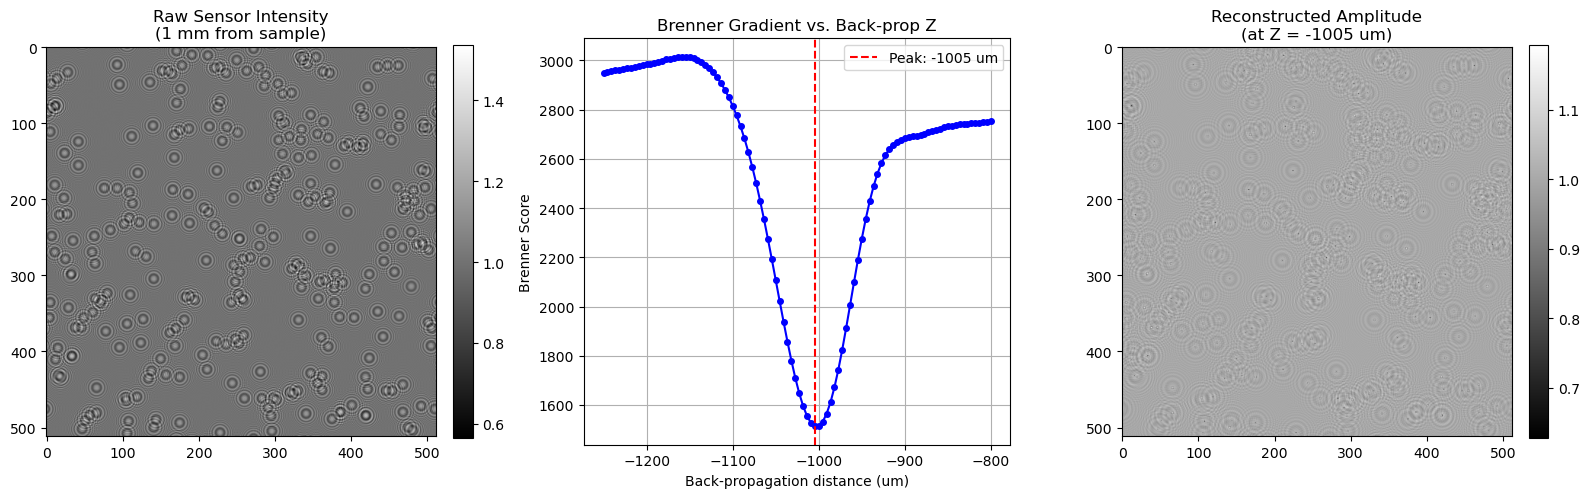

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def generate_3d_biological_sample(grid_size, dx, thickness, num_slices, num_cells=300):
    """
    Simulates a 3D biological sample containing spherical 'cells'.
    Returns a 3D array of refractive index variations (delta_n).
    """
    print(f"Generating 3D sample: {thickness}um thick, {num_slices} slices...")
    sample_vol = np.zeros((grid_size, grid_size, num_slices))
    
    # Cell parameters
    cell_radius_um = 5.0  
    cell_radius_px = int(cell_radius_um / dx)
    
    # Place random cells in the volume
    for _ in range(num_cells):
        cx = np.random.randint(cell_radius_px, grid_size - cell_radius_px)
        cy = np.random.randint(cell_radius_px, grid_size - cell_radius_px)
        cz = np.random.randint(0, num_slices)
        
        # Draw a sphere
        for x in range(cx - cell_radius_px, cx + cell_radius_px + 1):
            for y in range(cy - cell_radius_px, cy + cell_radius_px + 1):
                for z in range(max(0, cz - cell_radius_px), min(num_slices, cz + cell_radius_px + 1)):
                    if (x-cx)**2 + (y-cy)**2 + (z-cz)**2 <= cell_radius_px**2:
                        # Add biological refractive index perturbation (e.g., cell organelles)
                        sample_vol[x, y, z] = 0.04 * np.random.normal(1.0, 0.1) 
                        
    return sample_vol

def angular_spectrum_prop(field, dx, z, wavelength):
    """
    Propagates a complex 2D field using the Angular Spectrum Method.
    """
    N = field.shape[0]
    k = 2 * np.pi / wavelength
    
    # Setup spatial frequencies
    fx = np.fft.fftfreq(N, d=dx)
    fx, fy = np.meshgrid(fx, fx)
    
    # Transfer function formulation
    term = 1 - (wavelength * fx)**2 - (wavelength * fy)**2
    term[term < 0] = 0 # Evanescent wave filtering
    
    H = np.exp(1j * k * z * np.sqrt(term))
    
    # Forward FFT -> Multiply by Transfer Function -> Inverse FFT
    field_f = np.fft.fft2(field)
    return np.fft.ifft2(field_f * H)

def calculate_brenner_gradient(image):
    """
    Calculates the Brenner gradient for a given 2D image (intensity or amplitude).
    """
    # X-direction difference
    diff_x = image[2:, :] - image[:-2, :]
    # Y-direction difference
    diff_y = image[:, 2:] - image[:, :-2]
    
    # Sum of squared differences
    brenner = np.sum(diff_x**2) + np.sum(diff_y**2)
    return brenner

def main():
    # --- System Parameters ---
    wavelength = 0.532  # microns (e.g., 532 nm laser)
    dx = 3.68            # Pixel size in microns
    N = 512             # Grid size (N x N)
    
    sample_thickness = 50.0  # Total thickness in microns
    num_slices = 50           # Number of axial slices
    dz_slice = sample_thickness / num_slices # Distance between slices
    
    sensor_distance = 1000.0  # 1 mm away from the sample's exit plane
    
    # --- 1. Initialize Sample and Field ---
    sample_3d = generate_3d_biological_sample(N, dx, sample_thickness, num_slices)
    field = np.ones((N, N), dtype=np.complex128) # Illuminating plane wave
    
    # --- 2. Forward Propagation (Multi-slice BPM) ---
    print("Executing Multi-Slice Forward Propagation...")
    for i in range(num_slices):
        # Accumulate phase shift for this slice: phi = k * delta_n * dz
        phase_shift = (2 * np.pi / wavelength) * sample_3d[:, :, i] * dz_slice
        field = field * np.exp(1j * phase_shift)
        
        # Propagate to the next slice
        if i < num_slices - 1:
            field = angular_spectrum_prop(field, dx, dz_slice, wavelength)
            
    # Propagate from the exit plane to the sensor
    print(f"Propagating {sensor_distance}um to sensor...")
    sensor_field = angular_spectrum_prop(field, dx, sensor_distance, wavelength)
    
    # --- 3. Sensor Recording ---
    # The sensor only records intensity (losing the phase)
    sensor_intensity = np.abs(sensor_field)**2

    # --- 4. Z-Sweep Back-propagation ---
    print("Initiating Z-Sweep and Brenner Gradient calculation...")
    
    # We will sweep from a bit before the sensor distance up to past the sample start
    # Negative Z because we are back-propagating
    z_sweep_vals = np.linspace(-1250, -800, 100)
    brenner_scores = []
    reconstructed_volumes = []
    
    # We assume uniform phase for the backpropagation (holographic twin image will be present)
    field_to_backprop = np.sqrt(sensor_intensity) 
    
    for z_back in z_sweep_vals:
        recon_field = angular_spectrum_prop(field_to_backprop, dx, z_back, wavelength)
        recon_amp = np.abs(recon_field)
        
        b_score = calculate_brenner_gradient(recon_amp**2)
        brenner_scores.append(b_score)
        reconstructed_volumes.append(recon_amp)
        
    brenner_scores = np.array(brenner_scores)
    best_z_idx = np.argmin(brenner_scores)
    best_z = z_sweep_vals[best_z_idx]
    
    print(f"Sweep complete. Best focus found at Z = {best_z:.2f} um (relative to sensor)")

    # --- 5. Visualization ---
    fig, axs = plt.subplots(1, 3, figsize=(16, 5))
    
    # Plot 1: Sensor Intensity
    im0 = axs[0].imshow(sensor_intensity, cmap='gray')
    axs[0].set_title('Raw Sensor Intensity\n(1 mm from sample)')
    fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
    
    # Plot 2: Brenner Gradient Curve
    axs[1].plot(z_sweep_vals, brenner_scores, 'b-o', markersize=4)
    axs[1].axvline(best_z, color='r', linestyle='--', label=f'Peak: {best_z:.0f} um')
    axs[1].set_title('Brenner Gradient vs. Back-prop Z')
    axs[1].set_xlabel('Back-propagation distance (um)')
    axs[1].set_ylabel('Brenner Score')
    axs[1].legend()
    axs[1].grid(True)
    
    # Plot 3: Best Focused Reconstruction
    best_recon = reconstructed_volumes[best_z_idx]
    im2 = axs[2].imshow(best_recon, cmap='gray')
    axs[2].set_title(f'Reconstructed Amplitude\n(at Z = {best_z:.0f} um)')
    fig.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()